# Baku Sentinel — Flood Risk Forecasting
## End-to-End Pipeline: Ingest → ETL → EDA → Train → Evaluate → Forecast

**Architecture:** Bronze → Silver → Gold medallion (DuckDB) · 6-hourly granularity  
**Model:** XGBoost + isotonic calibration · chronological split · SHAP explainability  
**Forecast:** 15-day live Open-Meteo data · per-zone risk scores & alerts

## 0 · Setup

In [1]:
import sys, os, warnings
sys.path.append(os.path.abspath('../'))
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import duckdb
import shap
from scipy import stats
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay, classification_report,
    roc_auc_score, average_precision_score,
)

from src import config, ingestion, pipeline, model as mdl

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✓ Imports OK")
print(f"  DuckDB path : {config.DB_PATH}")
print(f"  Models dir  : {config.MODELS_DIR}")

✓ Imports OK
  DuckDB path : C:\Users\TEXNO\PycharmProjects\Ironhack_Weather_Prediction\Weather-Prediction\data\weather.duckdb
  Models dir  : C:\Users\TEXNO\PycharmProjects\Ironhack_Weather_Prediction\Weather-Prediction\models


## 1 · Historical Data Ingestion (Bronze Layer)

Fetches **hourly weather** (Open-Meteo Archive API) and **daily river discharge**  
(Open-Meteo Flood API) for all three Baku zones.  
Data is written to DuckDB bronze schema tables.

> **Skip this cell if bronze data already exists** — ingestion takes ~2–5 minutes.

In [2]:
# Run once. Comment out after first successful execution.
# ingestion.run_historical_ingest(
#     start=config.HISTORICAL_START,
#     end=config.HISTORICAL_END,
# )

# Verify bronze tables exist
conn = duckdb.connect(str(config.DB_PATH))
tables = conn.execute("SHOW ALL TABLES").df()
conn.close()

# DuckDB column names vary by version — use what's actually available
available_cols = tables.columns.tolist()
print(f"SHOW ALL TABLES columns: {available_cols}")

# Filter to bronze schema if the column exists
if 'schema' in available_cols:
    bronze_tables = tables[tables['schema'] == 'bronze']
else:
    bronze_tables = tables

# Display with only columns that exist
display_cols = [c for c in ['schema', 'name', 'column_names', 'column_types', 'temporary']
                if c in bronze_tables.columns]
print(f"\nBronze tables ({len(bronze_tables)} found):")
print(bronze_tables[display_cols].to_string(index=False) if not bronze_tables.empty
      else " No bronze tables yet — run ingestion.run_historical_ingest() above first.")


SHOW ALL TABLES columns: ['database', 'schema', 'name', 'column_names', 'column_types', 'temporary']

Bronze tables (6 found):
schema                        name                                                                                                                                                                              column_names                                                                         column_types  temporary
bronze       flood_raw_high_relief                                                                                                                                                             [time, river_discharge, zone]                                                         [TIMESTAMP, DOUBLE, VARCHAR]      False
bronze        flood_raw_low_relief                                                                                                                                                             [time, river_discharge, zone]                   

## 2 · ETL Pipeline — Silver & Gold Layers

- **Silver**: resamples hourly → 6-hourly, joins flood discharge
- **Gold**: applies Sentinel feature SQL (lags, rolling windows, cascade signal, indices)

> Skip if `gold.flood_features` already exists in DuckDB.

In [4]:
# ── Step 1: run the ETL (uncomment and run ONCE, then re-comment) ─────────────
# pipeline.run_pipeline()

# ── Step 2: verify Gold table exists, then load it ────────────────────────────
import duckdb as _ddb

conn = _ddb.connect(str(config.DB_PATH), read_only=True)
gold_exists = conn.execute("""
    SELECT count(*) FROM information_schema.tables
    WHERE table_schema = 'gold' AND table_name = 'flood_features'
""").fetchone()[0]
conn.close()

if not gold_exists:
    print("Gold table does not exist yet.")
    print("   Uncomment  pipeline.run_pipeline()  above and run this cell again.")
    print("   This will: Bronze → Silver (6h resample + flood join) → Gold (feature SQL)")
    raise SystemExit("Stop here — run ETL first.")

conn = _ddb.connect(str(config.DB_PATH), read_only=True)
df_gold = conn.execute("SELECT * FROM gold.flood_features").df()
conn.close()

df_gold['time_6h'] = pd.to_datetime(df_gold['time_6h'])
print(f"Gold table  : {df_gold.shape[0]:,} rows × {df_gold.shape[1]} columns")
print(f"Date range  : {df_gold['time_6h'].min().date()} → {df_gold['time_6h'].max().date()}")
print(f"Zones       : {df_gold['zone'].unique().tolist()}")
print(f"Flood rate  : {df_gold['is_flood'].mean()*100:.3f}%")
print(f"Columns     : {df_gold.columns.tolist()}")
df_gold.head(3)


Gold table  : 27,624 rows × 44 columns
Date range  : 2020-01-01 → 2026-04-20
Zones       : ['Moderate Relief', 'Low Relief', 'High Relief']
Flood rate  : 1.086%
Columns     : ['zone', 'time_6h', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'soil_temperature_0_to_7cm', 'et0_fao_evapotranspiration', 'river_discharge', 'precip_lag_6h', 'precip_lag_12h', 'precip_lag_24h', 'precip_lag_48h', 'discharge_lag_6h', 'discharge_lag_24h', 'temp_lag_24h', 'precip_roll_sum_24h', 'precip_roll_sum_48h', 'precip_roll_sum_72h', 'precip_roll_max_24h', 'discharge_roll_max_24h', 'humidity_roll_max_24h', 'et0_roll_sum_24h', 'api_7d', 'soil_saturation_index', 'soil_moisture_change_6h', 'soil_moisture_deficit', 'frozen_ground_flag', 'discharge_trend_6h', 'temp_trend_24h', 'et_deficit_6h', 'et_deficit_24h', 'humidity_precip_product', 'highland_precip_24h', 'highland_discharge_6h', 'zone_cascade_risk', 'hour_sin', 'hour_cos', 'd

,zone,time_6h,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_temperature_0_to_7cm,et0_fao_evapotranspiration,river_discharge,precip_lag_6h,precip_lag_12h,precip_lag_24h,precip_lag_48h,discharge_lag_6h,discharge_lag_24h,temp_lag_24h,precip_roll_sum_24h,precip_roll_sum_48h,precip_roll_sum_72h,precip_roll_max_24h,discharge_roll_max_24h,humidity_roll_max_24h,et0_roll_sum_24h,api_7d,soil_saturation_index,soil_moisture_change_6h,soil_moisture_deficit,frozen_ground_flag,discharge_trend_6h,temp_trend_24h,et_deficit_6h,et_deficit_24h,humidity_precip_product,highland_precip_24h,highland_discharge_6h,zone_cascade_risk,hour_sin,hour_cos,doy_sin,doy_cos,is_winter,is_flood
0,Moderate Relief,2024-03-16 00:00:00,5.9833,99.0000,0.0000,12.4167,0.2903,0.2600,7.4167,0.0000,0.0500,0.0000,0.0000,0.1000,0.2000,0.0600,0.0600,6.3333,0.2000,0.3000,0.5000,0.2000,0.0600,99.0000,1.8000,0.0522,0.2752,-0.0012,0.1748,0,-0.0100,-0.3500,0.0000,-1.6000,0.0000,0.6000,0.0300,0.4000,0.0000,1.0000,0.9657,0.2595,0,0
1,Moderate Relief,2024-03-16 06:00:00,7.1667,92.0000,0.2000,20.8167,0.2910,0.2600,7.8333,0.3700,0.0500,0.0000,0.0000,0.2000,0.0000,0.0500,0.0600,7.0167,0.2000,0.5000,0.7000,0.2000,0.0600,99.0000,1.8600,0.3044,0.2755,0.0007,0.1745,0,0.0000,0.1500,-0.1700,-1.6600,18.4000,0.6000,0.0300,0.4000,1.0000,0.0000,0.9657,0.2595,0,0
2,Moderate Relief,2024-03-16 12:00:00,9.9000,73.0000,0.0000,29.3000,0.2860,0.2593,11.7333,1.2200,0.0500,0.2000,0.0000,0.0000,0.0000,0.0500,0.0600,11.1833,0.2000,0.5000,0.7000,0.2000,0.0600,99.0000,1.6600,0.1700,0.2727,-0.0050,0.1773,0,0.0000,-1.2833,-1.2200,-1.4600,0.0000,0.6000,0.0300,0.4000,0.0000,-1.0000,0.9657,0.2595,0,0


## 3 · Exploratory Data Analysis

### 3.1 · Missing values & data quality

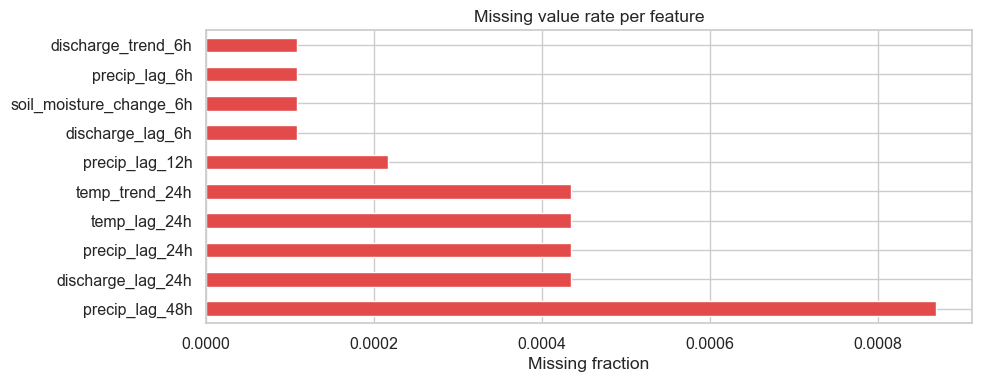

Total NaN cells: 90
                                           mean     std                  min  \
time_6h                     2023-02-24 21:00:00     NaN  2020-01-01 00:00:00   
temperature_2m                          15.2142  8.7648              -7.2167   
relative_humidity_2m                    71.2003 16.3230              13.8333   
precipitation                            0.2040  1.0612               0.0000   
wind_speed_10m                          17.9693 10.1555               0.9000   
soil_moisture_0_to_7cm                   0.1700  0.0998               0.0000   
soil_moisture_7_to_28cm                  0.2045  0.0574               0.1050   
soil_temperature_0_to_7cm               16.6100  9.8510              -4.1667   
et0_fao_evapotranspiration               0.8250  0.9718               0.0000   
river_discharge                          0.1224  0.5778               0.0000   
precip_lag_6h                            0.2041  1.0613               0.0000   
precip_lag_12h      

In [5]:
miss = df_gold.isnull().mean().sort_values(ascending=False)
miss_nonzero = miss[miss > 0]

fig, ax = plt.subplots(figsize=(10, 4))
if not miss_nonzero.empty:
    miss_nonzero.plot(kind='barh', ax=ax, color='#E24B4A')
    ax.set_xlabel('Missing fraction')
    ax.set_title('Missing value rate per feature')
else:
    ax.text(0.5, 0.5, 'No missing values', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)
    ax.set_title('Data quality: Gold layer')
plt.tight_layout()
plt.show()

print(f"Total NaN cells: {df_gold.isnull().sum().sum():,}")
print(df_gold.describe().T[['mean','std','min','max']].round(3))

### 3.2 · Flood event distribution by zone & season

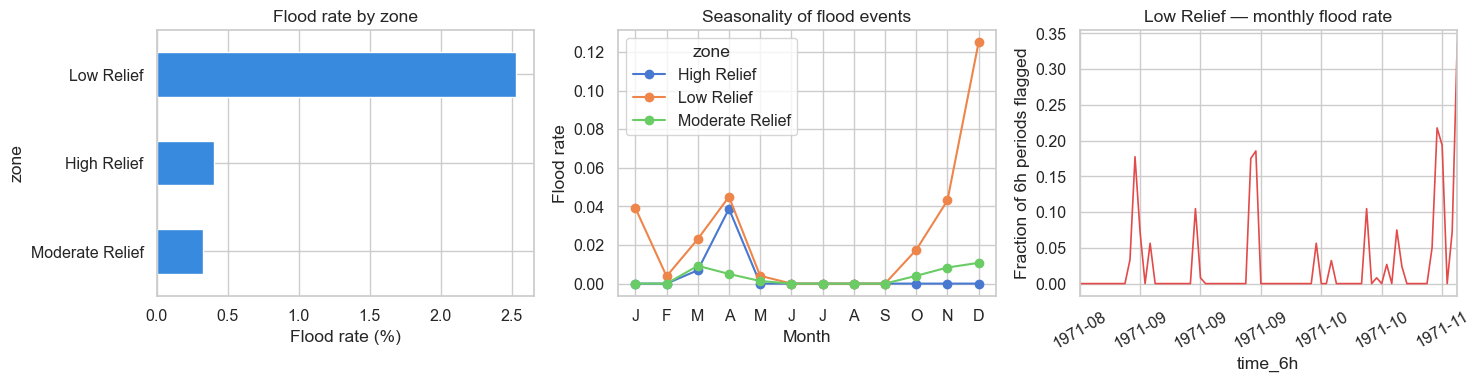

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Flood rate per zone
flood_by_zone = df_gold.groupby('zone')['is_flood'].mean() * 100
flood_by_zone.sort_values().plot(kind='barh', ax=axes[0], color='#378ADD')
axes[0].set_xlabel('Flood rate (%)')
axes[0].set_title('Flood rate by zone')

# Flood events over time
df_gold['month'] = df_gold['time_6h'].dt.month
monthly = df_gold.groupby(['month', 'zone'])['is_flood'].mean().unstack()
monthly.plot(ax=axes[1], marker='o', linewidth=1.5)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Flood rate')
axes[1].set_title('Seasonality of flood events')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

# Time-series of is_flood for Low Relief
lr = df_gold[df_gold['zone'] == 'Low Relief'].set_index('time_6h')['is_flood']
lr_monthly = lr.resample('ME').mean()
lr_monthly.plot(ax=axes[2], color='#E24B4A', linewidth=1.2)
axes[2].set_title('Low Relief — monthly flood rate')
axes[2].set_ylabel('Fraction of 6h periods flagged')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

### 3.3 · Correlation analysis — Spearman ρ with is_flood

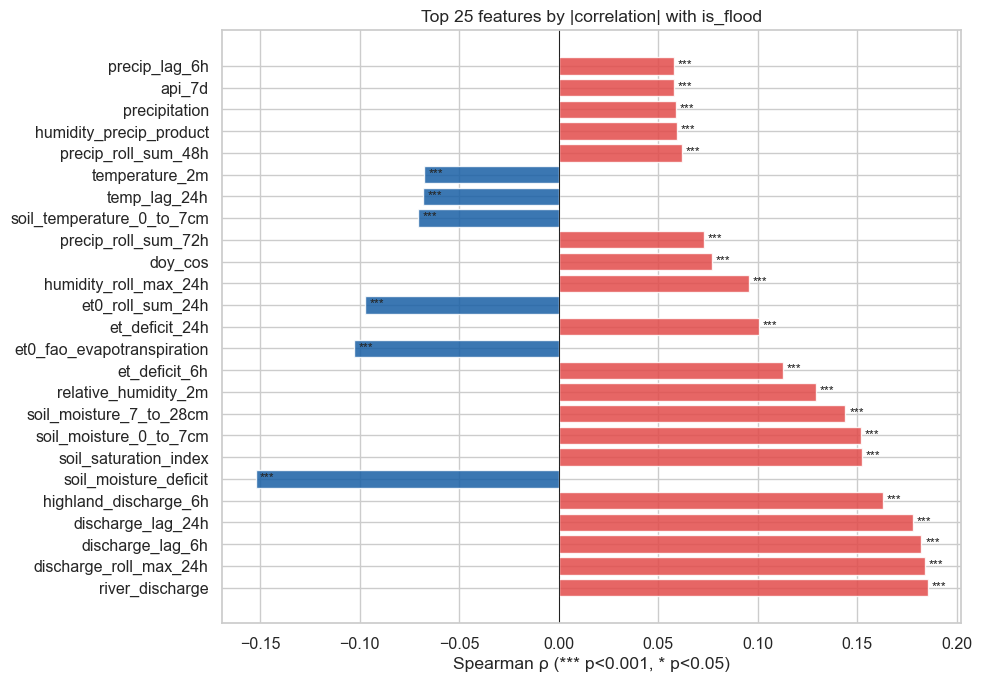


Top 10 positively correlated:
                feature    rho   pval
        river_discharge 0.1853 0.0000
 discharge_roll_max_24h 0.1839 0.0000
       discharge_lag_6h 0.1822 0.0000
      discharge_lag_24h 0.1778 0.0000
  highland_discharge_6h 0.1628 0.0000
  soil_saturation_index 0.1523 0.0000
 soil_moisture_0_to_7cm 0.1518 0.0000
soil_moisture_7_to_28cm 0.1440 0.0000
   relative_humidity_2m 0.1291 0.0000
          et_deficit_6h 0.1125 0.0000

Top 5 negatively correlated:
                   feature     rho   pval
     soil_moisture_deficit -0.1523 0.0000
et0_fao_evapotranspiration -0.1026 0.0000
          et0_roll_sum_24h -0.0972 0.0000
 soil_temperature_0_to_7cm -0.0706 0.0000
              temp_lag_24h -0.0681 0.0000


In [7]:
num_cols = df_gold.select_dtypes(include='number').columns.tolist()
target   = 'is_flood'
y = df_gold[target]

corr_rows = []
for col in num_cols:
    if col == target: continue
    x = df_gold[col].dropna()
    common = x.index.intersection(y.index)
    if len(common) < 50: continue
    rho, pval = stats.spearmanr(x.loc[common], y.loc[common])
    corr_rows.append({'feature': col, 'rho': rho, 'pval': pval})

corr_df = (pd.DataFrame(corr_rows)
           .assign(abs_rho=lambda d: d['rho'].abs())
           .sort_values('abs_rho', ascending=False)
           .head(25))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E24B4A' if r > 0 else '#185FA5' for r in corr_df['rho']]
bars = ax.barh(corr_df['feature'], corr_df['rho'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.6)
for bar, pval in zip(bars, corr_df['pval']):
    if pval < 0.001:
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                '***', va='center', fontsize=9)
    elif pval < 0.05:
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                '*', va='center', fontsize=9)
ax.set_xlabel('Spearman ρ (*** p<0.001, * p<0.05)')
ax.set_title('Top 25 features by |correlation| with is_flood')
plt.tight_layout()
plt.show()

print("\nTop 10 positively correlated:")
print(corr_df[corr_df['rho']>0].head(10)[['feature','rho','pval']].to_string(index=False))
print("\nTop 5 negatively correlated:")
print(corr_df[corr_df['rho']<0].head(5)[['feature','rho','pval']].to_string(index=False))

### 3.4 · Mann-Whitney U test — flood vs. non-flood distributions

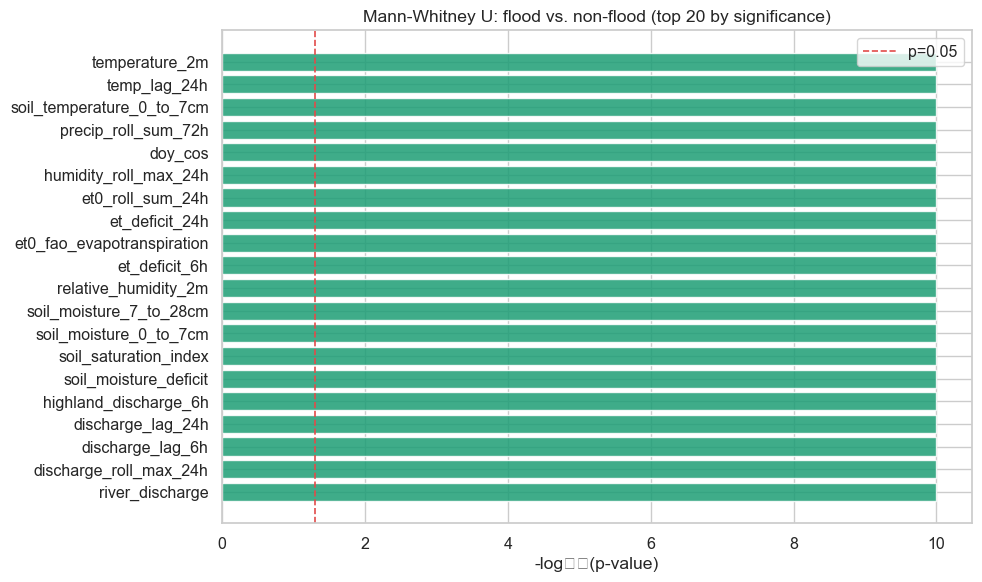

Significant features (p<0.05): 20 / 20
                feature  flood_median  no_flood_median   delta   pval
        river_discharge        2.0150           0.0100  2.0050 0.0000
 discharge_roll_max_24h        2.2100           0.0100  2.2000 0.0000
       discharge_lag_6h        2.0000           0.0100  1.9900 0.0000
      discharge_lag_24h        1.9950           0.0100  1.9850 0.0000
  highland_discharge_6h        0.1450           0.0100  0.1350 0.0000
  soil_moisture_deficit        0.1298           0.2817 -0.1518 0.0000
  soil_saturation_index        0.3202           0.1683  0.1518 0.0000
 soil_moisture_0_to_7cm        0.3276           0.1608  0.1667 0.0000
soil_moisture_7_to_28cm        0.3185           0.1863  0.1322 0.0000
   relative_humidity_2m       88.6667          73.5000 15.1667 0.0000


In [8]:
flood    = df_gold[df_gold['is_flood'] == 1]
no_flood = df_gold[df_gold['is_flood'] == 0]

mw_rows = []
for col in num_cols:
    if col == 'is_flood': continue
    f  = flood[col].dropna()
    nf = no_flood[col].dropna()
    if len(f) < 10 or len(nf) < 10: continue
    stat, pval = stats.mannwhitneyu(f, nf, alternative='two-sided')
    mw_rows.append({
        'feature':      col,
        'flood_median': f.median(),
        'no_flood_median': nf.median(),
        'delta':        f.median() - nf.median(),
        'pval':         pval,
        'significant':  pval < 0.05,
    })

mw_df = pd.DataFrame(mw_rows).sort_values('pval').head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1D9E75' if s else '#B4B2A9' for s in mw_df['significant']]
ax.barh(mw_df['feature'], -np.log10(mw_df['pval'] + 1e-10), color=colors, alpha=0.85)
ax.axvline(-np.log10(0.05), color='#E24B4A', linestyle='--', linewidth=1.2, label='p=0.05')
ax.set_xlabel('-log₁₀(p-value)')
ax.set_title('Mann-Whitney U: flood vs. non-flood (top 20 by significance)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Significant features (p<0.05): {mw_df['significant'].sum()} / {len(mw_df)}")
print(mw_df[['feature','flood_median','no_flood_median','delta','pval']].head(10).to_string(index=False))

### 3.5 · Feature distributions — flood vs. non-flood

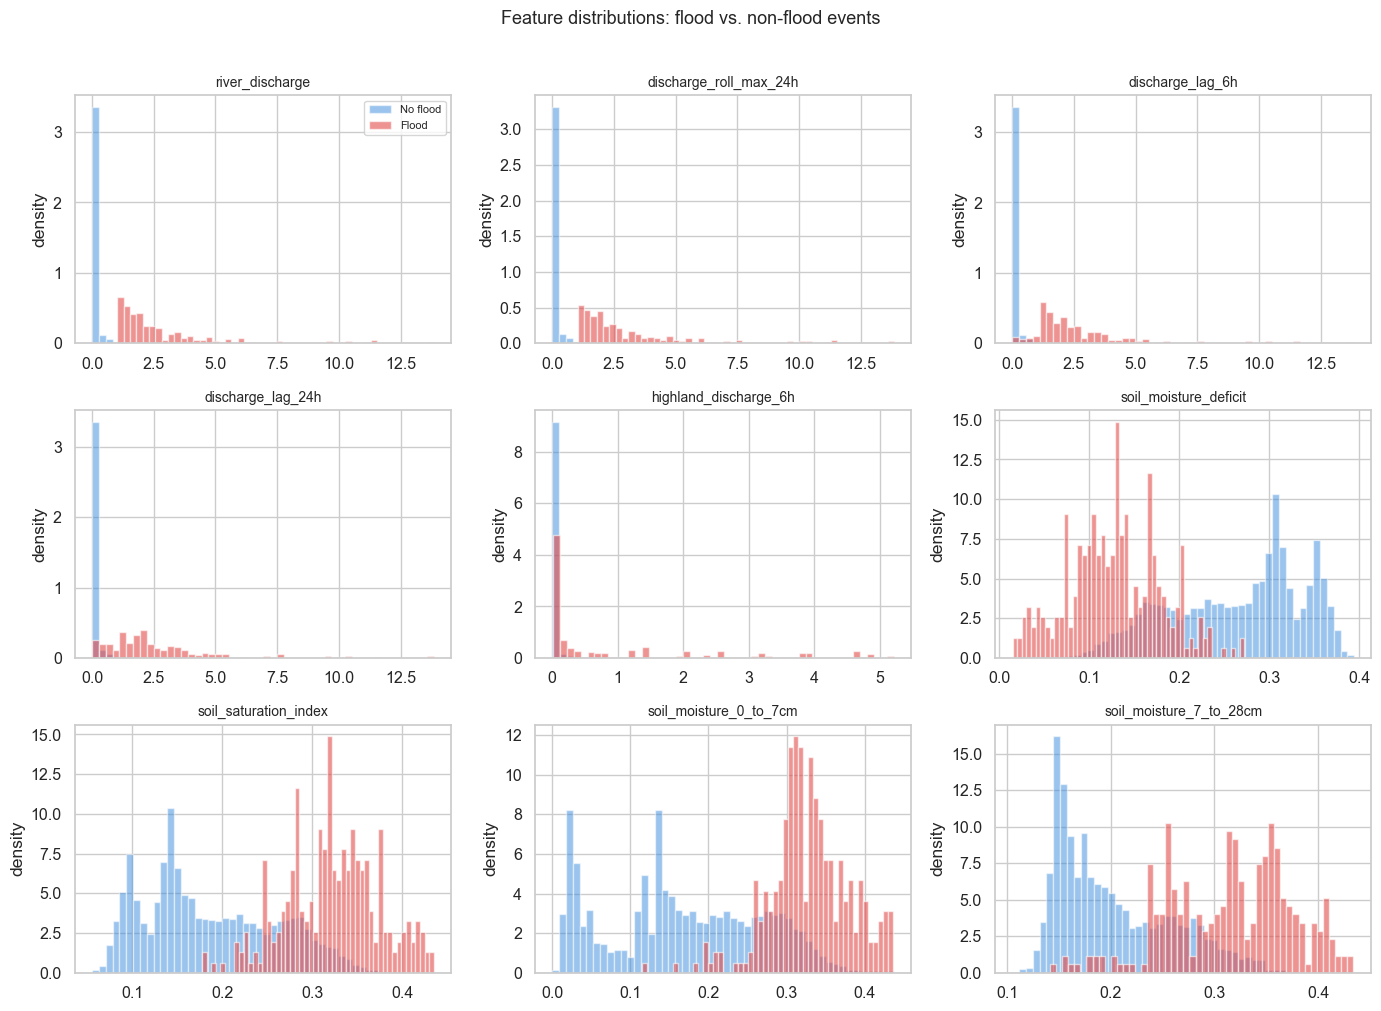

In [9]:
top_features = corr_df['feature'].head(9).tolist()

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    f_vals  = flood[feat].dropna()
    nf_vals = no_flood[feat].dropna()
    ax.hist(nf_vals, bins=50, alpha=0.5, color='#378ADD', density=True, label='No flood')
    ax.hist(f_vals,  bins=50, alpha=0.6, color='#E24B4A', density=True, label='Flood')
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel('density')
    if i == 0: ax.legend(fontsize=8)

plt.suptitle('Feature distributions: flood vs. non-flood events', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 3.6 · Correlation heatmap — top engineered features

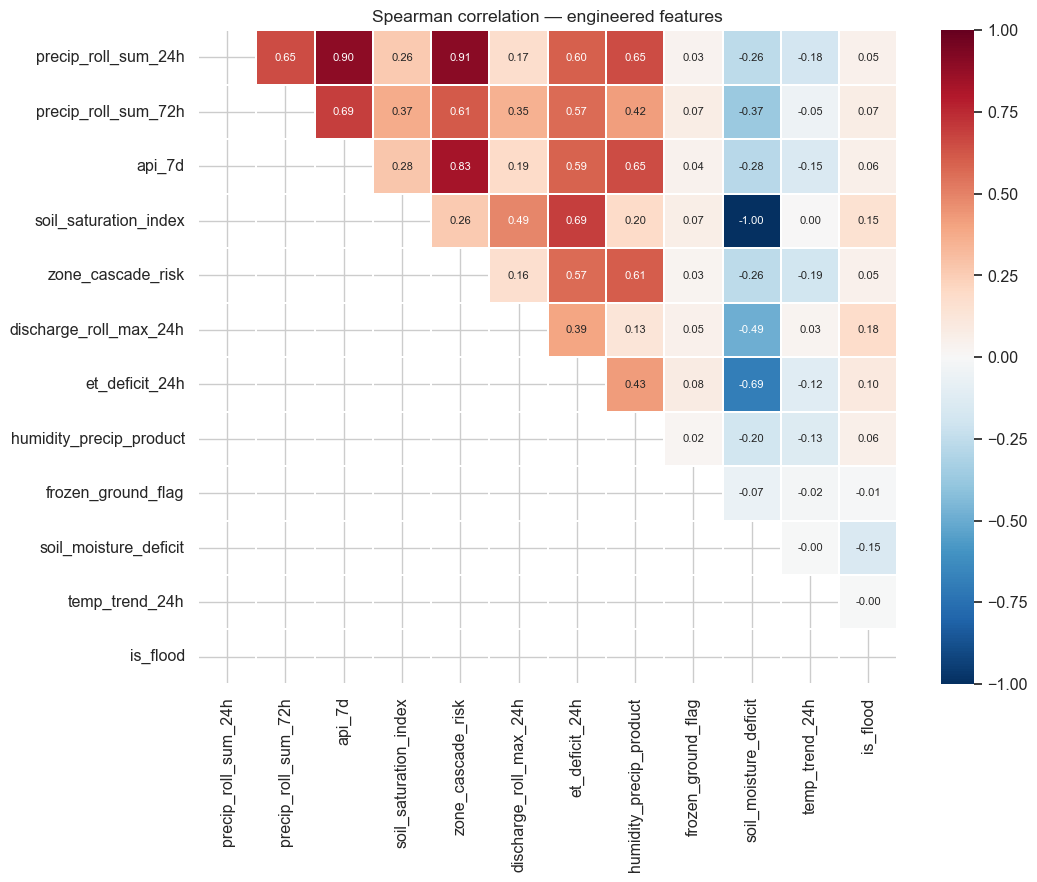

In [10]:
eng_features = [
    'precip_roll_sum_24h', 'precip_roll_sum_72h', 'api_7d',
    'soil_saturation_index', 'zone_cascade_risk', 'discharge_roll_max_24h',
    'et_deficit_24h', 'humidity_precip_product', 'frozen_ground_flag',
    'soil_moisture_deficit', 'temp_trend_24h', 'is_flood'
]
eng_features = [f for f in eng_features if f in df_gold.columns]

fig, ax = plt.subplots(figsize=(11, 9))
corr_matrix = df_gold[eng_features].corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=~mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax,
    annot_kws={'size': 8}, linewidths=0.3,
)
ax.set_title('Spearman correlation — engineered features')
plt.tight_layout()
plt.show()

## 4 · Model Training

XGBoost classifier with:
- Chronological train/test split (last 20% of time = test)
- `scale_pos_weight` to handle class imbalance
- Isotonic calibration for reliable probabilities
- F1-maximising threshold optimisation

In [25]:
import importlib
importlib.reload(mdl) # Reloads src.model
bundle = mdl.train(df_gold, calibrate=True)

In [26]:
print("\n── Model Metrics ──────────────────────────────────────────")
for k, v in bundle['metrics'].items():
    if k not in ('report', 'cv_auc_pr_mean', 'cv_auc_pr_std'):
        print(f"  {k:25s}: {v}")
print(f"  {'cv_auc_pr':25s}: {bundle['metrics']['cv_auc_pr_mean']:.4f} ± {bundle['metrics']['cv_auc_pr_std']:.4f}")


── Model Metrics ──────────────────────────────────────────
  auc_roc                  : 0.9967
  auc_pr                   : 0.9845
  f1_score                 : 0.7252
  threshold                : 0.7697
  n_train                  : 22098
  n_test                   : 5526
  pos_rate_train           : 0.006063897185265635
  pos_rate_test            : 0.030039811798769453
  cv_auc_pr                : 0.9961 ± 0.0037


## 5 · Model Evaluation

### 5.1 · ROC, Precision-Recall curves & Confusion Matrix

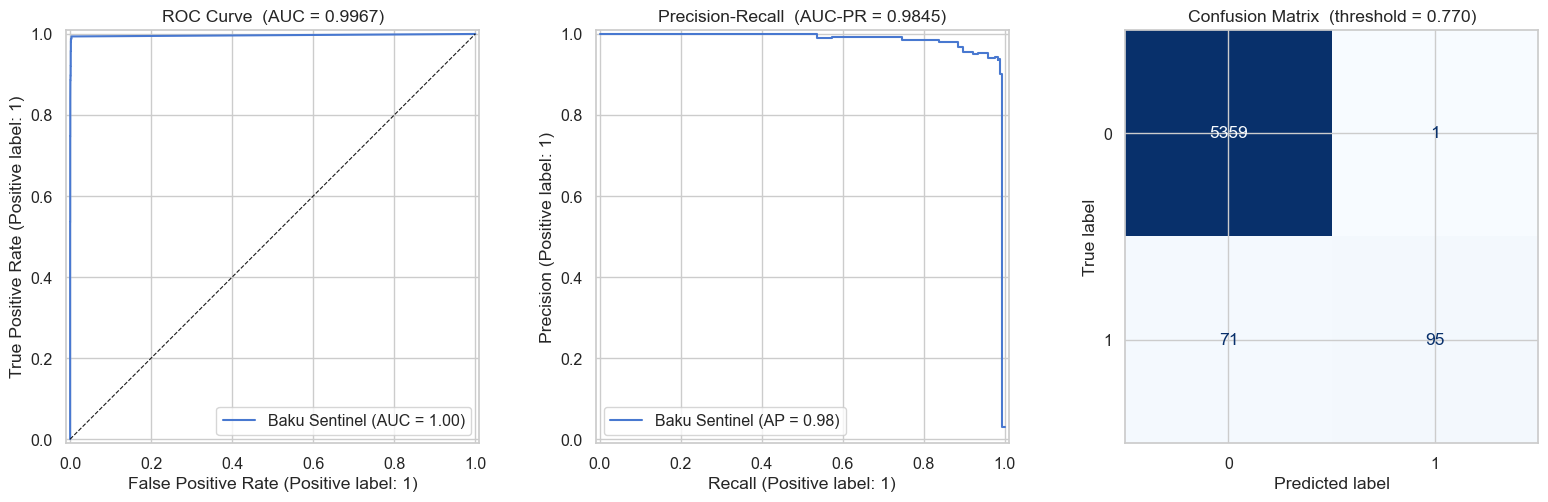


Classification Report:
              precision    recall  f1-score   support

    No Flood       0.99      1.00      0.99      5360
       Flood       0.99      0.57      0.73       166

    accuracy                           0.99      5526
   macro avg       0.99      0.79      0.86      5526
weighted avg       0.99      0.99      0.99      5526



In [27]:
test_df   = bundle['test_df']
y_test    = test_df['is_flood'].values
y_prob    = test_df['risk_score'].values
y_pred    = test_df['flood_pred'].values
threshold = bundle['threshold']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], name='Baku Sentinel')
axes[0].plot([0,1],[0,1],'k--',lw=0.8)
axes[0].set_title(f"ROC Curve  (AUC = {roc_auc_score(y_test, y_prob):.4f})")

# Precision-Recall
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='Baku Sentinel')
axes[1].set_title(f"Precision-Recall  (AUC-PR = {average_precision_score(y_test, y_prob):.4f})")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[2],
                                         colorbar=False, cmap='Blues')
axes[2].set_title(f"Confusion Matrix  (threshold = {threshold:.3f})")

plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Flood','Flood'], zero_division=0))

### 5.2 · Calibration curve

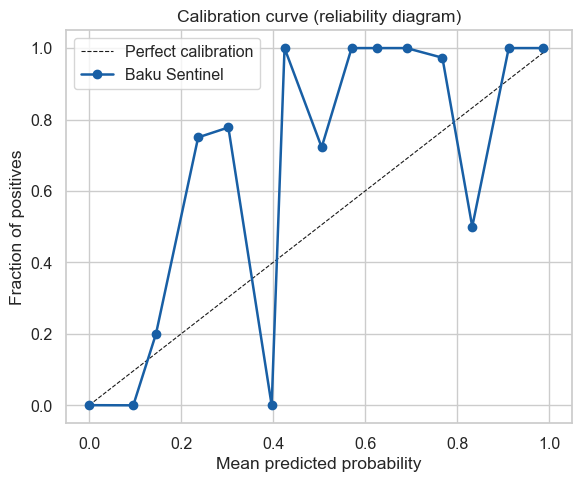

In [28]:
from sklearn.calibration import calibration_curve

fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=15, strategy='uniform')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0,1],[0,1],'k--',lw=0.8, label='Perfect calibration')
ax.plot(mean_pred, fraction_pos, 'o-', color='#185FA5', lw=1.8,
        label='Baku Sentinel', markersize=6)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration curve (reliability diagram)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 · Threshold sensitivity — F1, Precision, Recall vs. threshold

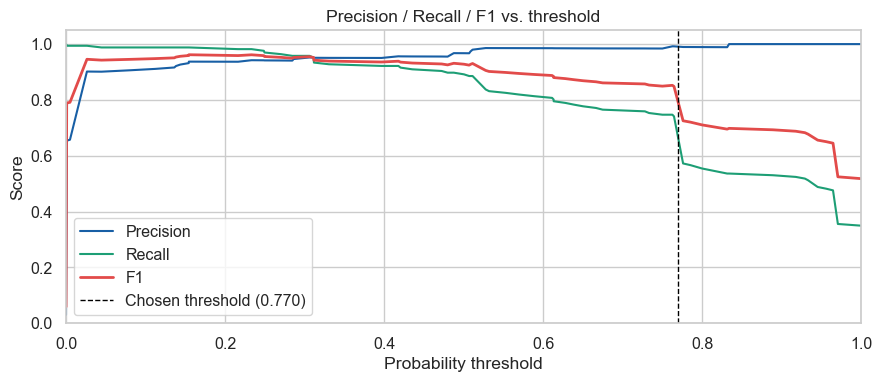

In [29]:
from sklearn.metrics import precision_recall_curve, f1_score as f1s

precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_prob)
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-9)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds_arr, precision_arr[:-1], label='Precision', color='#185FA5', lw=1.5)
ax.plot(thresholds_arr, recall_arr[:-1],    label='Recall',    color='#1D9E75', lw=1.5)
ax.plot(thresholds_arr, f1_arr[:-1],        label='F1',        color='#E24B4A', lw=2)
ax.axvline(threshold, color='black', linestyle='--', lw=1, label=f'Chosen threshold ({threshold:.3f})')
ax.set_xlabel('Probability threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs. threshold')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### 5.4 · Risk score distribution by true label

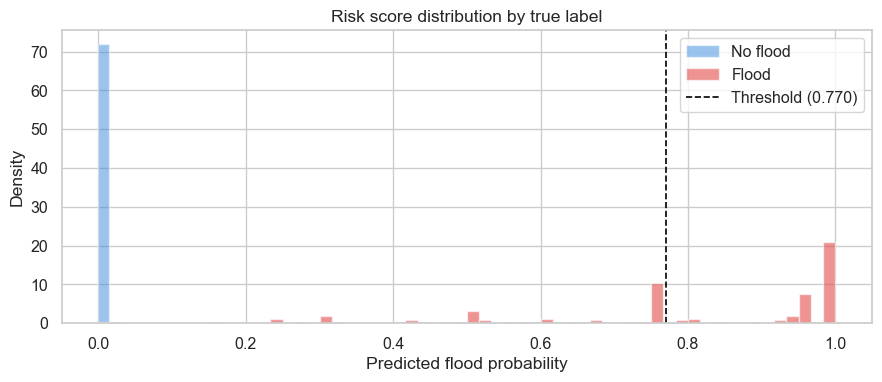

In [30]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(test_df[test_df['is_flood']==0]['risk_score'], bins=60,
        alpha=0.5, color='#378ADD', density=True, label='No flood')
ax.hist(test_df[test_df['is_flood']==1]['risk_score'], bins=60,
        alpha=0.6, color='#E24B4A', density=True, label='Flood')
ax.axvline(threshold, color='black', linestyle='--', lw=1.2,
           label=f'Threshold ({threshold:.3f})')
ax.set_xlabel('Predicted flood probability')
ax.set_ylabel('Density')
ax.set_title('Risk score distribution by true label')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 · Temporal error analysis — risk score over test period

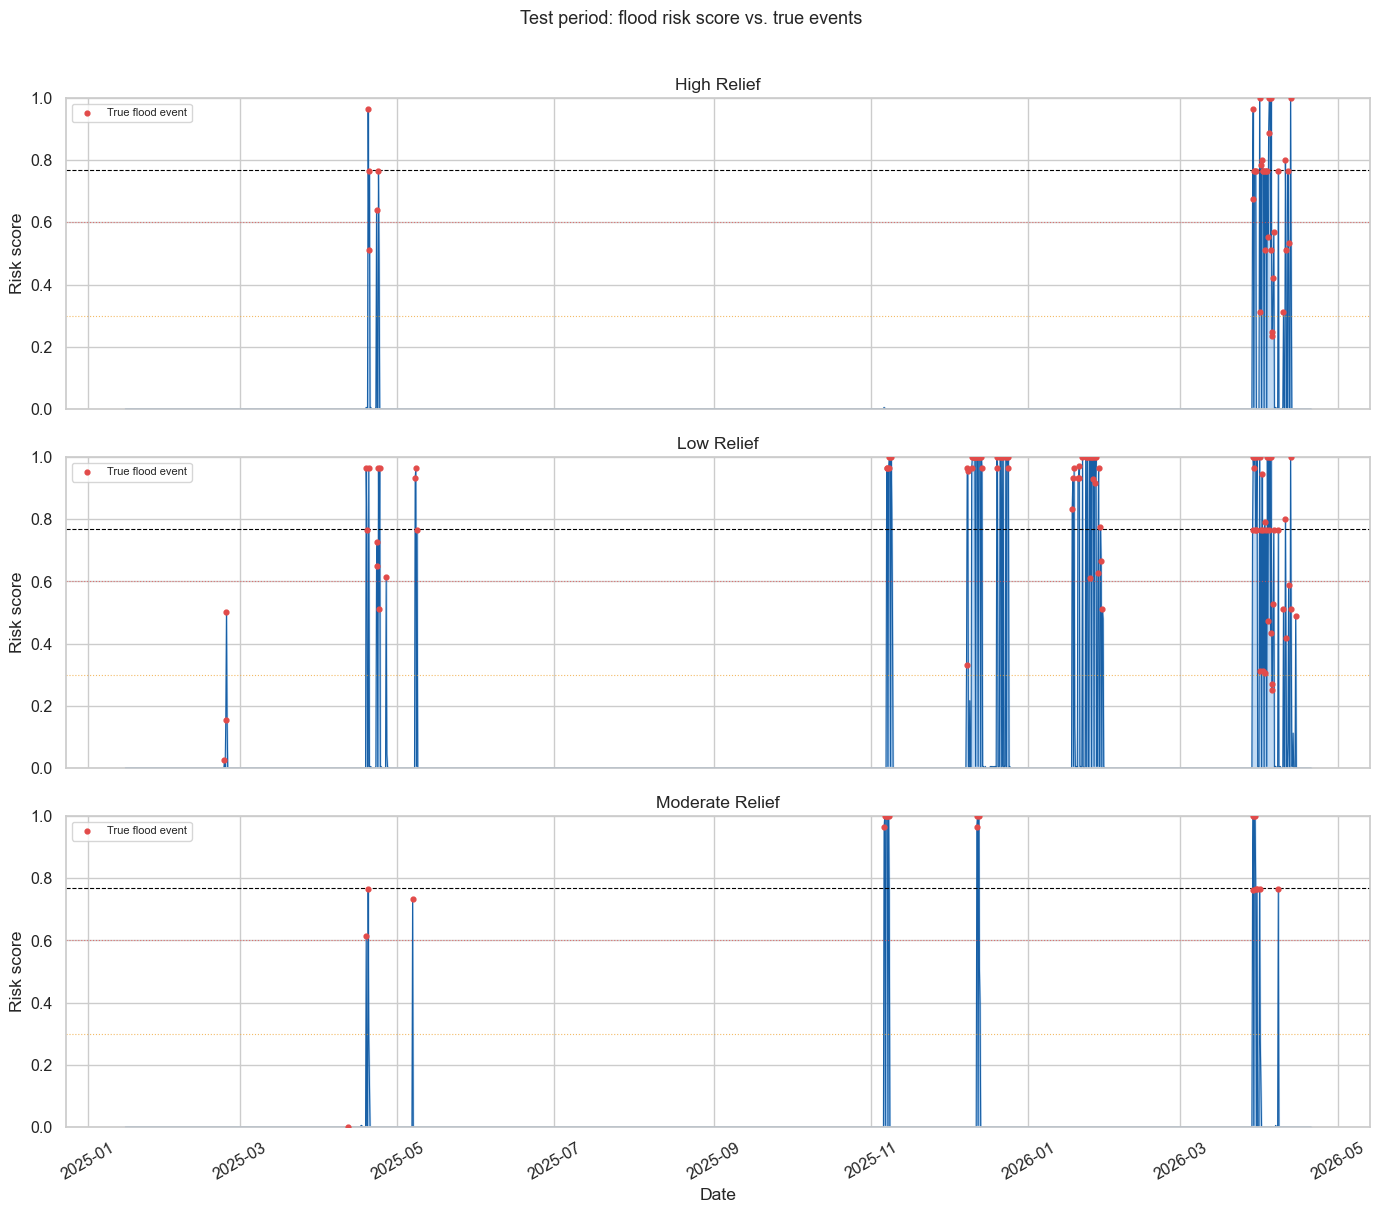

In [31]:
fig, axes = plt.subplots(len(config.BAKU_ZONES), 1,
                          figsize=(14, 4 * len(config.BAKU_ZONES)), sharex=True)

for ax, zone_cfg in zip(axes, config.BAKU_ZONES):
    zone = zone_cfg['zone']
    zdf  = test_df[test_df['zone'] == zone].sort_values('time_6h')
    ax.fill_between(zdf['time_6h'], zdf['risk_score'], alpha=0.3, color='#378ADD')
    ax.plot(zdf['time_6h'], zdf['risk_score'], lw=0.8, color='#185FA5')
    floods = zdf[zdf['is_flood'] == 1]
    ax.scatter(floods['time_6h'], floods['risk_score'],
               color='#E24B4A', s=12, zorder=5, label='True flood event')
    ax.axhline(threshold, color='black', linestyle='--', lw=0.8)
    ax.axhline(config.RISK_HIGH,   color='#E24B4A', linestyle=':', lw=0.8, alpha=0.7)
    ax.axhline(config.RISK_MEDIUM, color='#EF9F27', linestyle=':', lw=0.8, alpha=0.7)
    ax.set_ylabel('Risk score')
    ax.set_title(f'{zone}')
    ax.set_ylim(0, 1)
    if floods.shape[0] > 0:
        ax.legend(fontsize=8)

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
plt.suptitle('Test period: flood risk score vs. true events', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6 · SHAP Feature Importance & Explainability

In [33]:
# Rebuild SHAP values for the test set
checkpoint = mdl.load_model()
feature_cols = checkpoint['features']

drop_cols = ['time_6h', 'river_discharge', 'is_flood',
             'risk_score', 'flood_pred', 'risk_level']
X_test_raw = pd.get_dummies(
    test_df.drop(columns=[c for c in drop_cols if c in test_df.columns]),
    columns=['zone'], drop_first=True
)
for c in feature_cols:
    if c not in X_test_raw.columns:
        X_test_raw[c] = 0
X_test_enc = X_test_raw[feature_cols].fillna(0)

# Get the base XGBoost estimator for SHAP
base_model = checkpoint['model']
if hasattr(base_model, 'estimator'):          # CalibratedClassifierCV
    base_model = base_model.estimator

explainer   = shap.TreeExplainer(base_model)
shap_values = explainer.shap_values(X_test_enc)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values computed for {X_test_enc.shape[0]:,} test samples.")

SHAP values computed for 5,526 test samples.


### 6.1 · Global feature importance (mean |SHAP|)

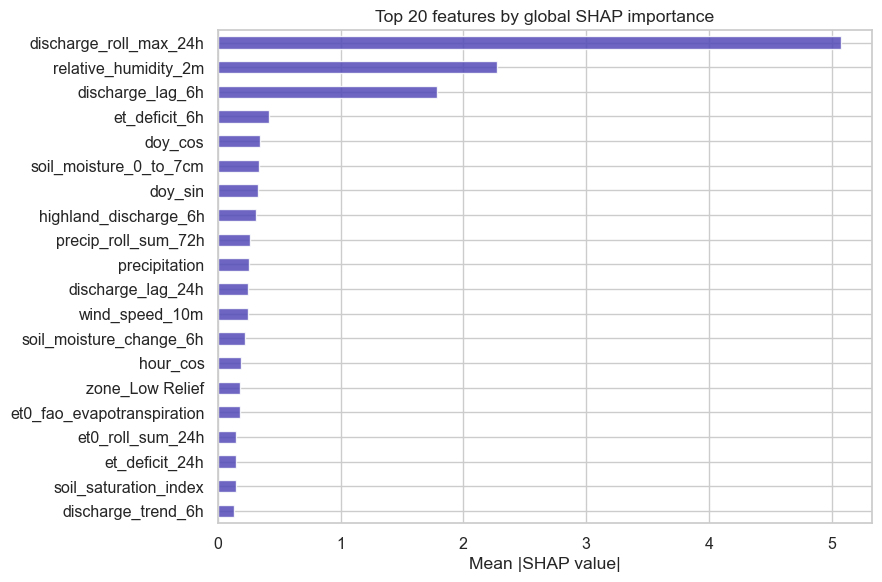

Top 15 features:
discharge_roll_max_24h    5.0750
relative_humidity_2m      2.2749
discharge_lag_6h          1.7863
et_deficit_6h             0.4141
doy_cos                   0.3467
soil_moisture_0_to_7cm    0.3327
doy_sin                   0.3316
highland_discharge_6h     0.3155
precip_roll_sum_72h       0.2648
precipitation             0.2513
discharge_lag_24h         0.2477
wind_speed_10m            0.2463
soil_moisture_change_6h   0.2203
hour_cos                  0.1919
zone_Low Relief           0.1826


In [34]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_ser = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
shap_ser.sort_values().plot(kind='barh', ax=ax, color='#534AB7', alpha=0.85)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 features by global SHAP importance')
plt.tight_layout()
plt.show()

print("Top 15 features:")
print(shap_ser.head(15).to_string())

### 6.2 · SHAP summary plot (beeswarm)

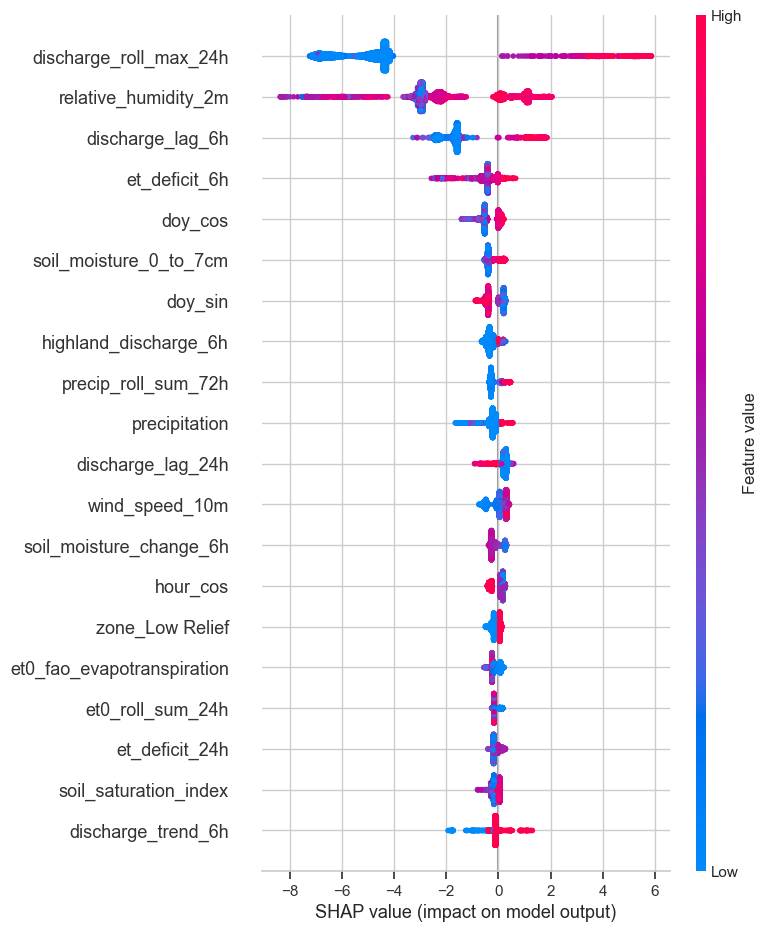

In [35]:
shap.summary_plot(shap_values, X_test_enc,
                  feature_names=feature_cols,
                  max_display=20,
                  show=True)

### 6.3 · SHAP dependence plots — top 4 features

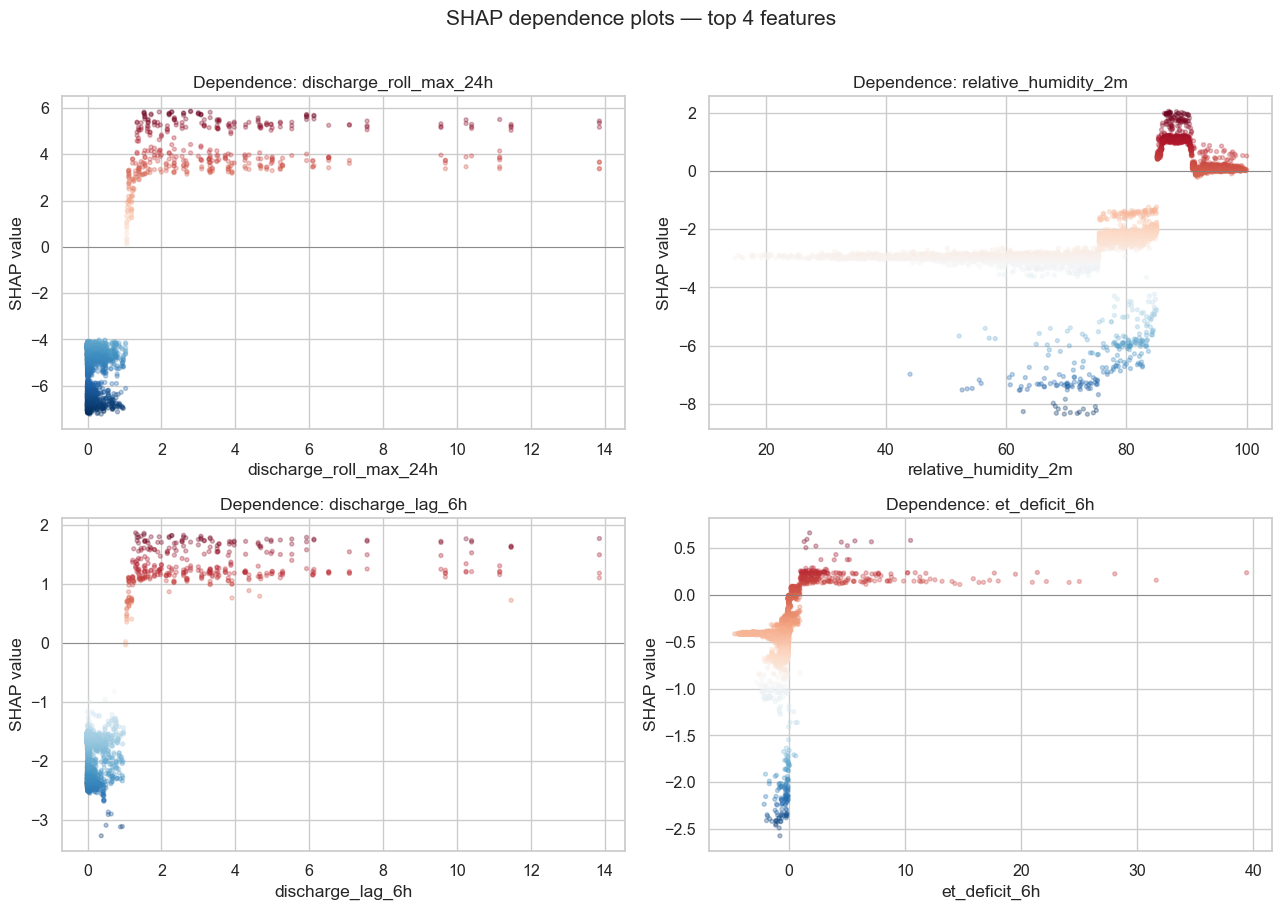

In [36]:
top4 = shap_ser.index[:4].tolist()
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, feat in zip(axes.flatten(), top4):
    if feat not in X_test_enc.columns:
        continue
    idx = feature_cols.index(feat)
    ax.scatter(X_test_enc[feat], shap_values[:, idx],
               alpha=0.3, s=8, c=shap_values[:, idx],
               cmap='RdBu_r')
    ax.axhline(0, color='gray', lw=0.6)
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'Dependence: {feat}')

plt.suptitle('SHAP dependence plots — top 4 features', y=1.01)
plt.tight_layout()
plt.show()

## 7 · Live 15-Day Flood Risk Forecast

Fetches real-time data from Open-Meteo, processes through the Sentinel pipeline,
and scores with the trained model.

In [37]:
# 7.1 Fetch live forecast
df_forecast_raw = ingestion.fetch_all_forecast(forecast_days=config.FORECAST_DAYS)
print(f"Live forecast: {len(df_forecast_raw):,} hourly rows across "
      f"{df_forecast_raw['zone'].nunique()} zones")
df_forecast_raw.head(3)

Live forecast: 1,080 hourly rows across 3 zones


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_temperature_0_to_7cm,et0_fao_evapotranspiration,zone
0,2026-04-25 00:00:00,10.3000,90,0.0000,10.3000,0.1760,0.2860,11.4000,0.0000,High Relief
1,2026-04-25 01:00:00,9.7000,89,0.0000,21.3000,0.1770,0.2860,11.1000,0.0100,High Relief
2,2026-04-25 02:00:00,9.7000,87,0.0000,22.9000,0.1770,0.2860,10.9000,0.0100,High Relief


In [38]:
# 7.2 Run through Sentinel pipeline (Silver stream → Gold features)
df_features = pipeline.run_forecast_pipeline(df_forecast_raw)
print(f"Engineered features: {df_features.shape}")
df_features.head(3)

Engineered features: (168, 44)


,zone,time_6h,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_temperature_0_to_7cm,et0_fao_evapotranspiration,river_discharge,precip_lag_6h,precip_lag_12h,precip_lag_24h,precip_lag_48h,discharge_lag_6h,discharge_lag_24h,temp_lag_24h,precip_roll_sum_24h,precip_roll_sum_48h,precip_roll_sum_72h,precip_roll_max_24h,discharge_roll_max_24h,humidity_roll_max_24h,et0_roll_sum_24h,api_7d,soil_saturation_index,soil_moisture_change_6h,soil_moisture_deficit,frozen_ground_flag,discharge_trend_6h,temp_trend_24h,et_deficit_6h,et_deficit_24h,humidity_precip_product,highland_precip_24h,highland_discharge_6h,zone_cascade_risk,hour_sin,hour_cos,doy_sin,doy_cos,is_winter,is_flood
0,Moderate Relief,2026-04-26 00:00:00,7.7500,91.0000,0.0000,6.5500,0.1428,0.2615,9.7167,0.0100,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,9.7833,0.0000,0.0000,0.0000,0.0000,0.0000,91.0000,2.4100,0.0000,0.2022,0.0027,0.2478,0,0.0000,-2.0333,-0.0100,-2.4100,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.9106,-0.4133,0,0
1,Moderate Relief,2026-04-26 06:00:00,10.7500,81.5000,0.0000,9.0333,0.1435,0.2605,11.2000,0.8600,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,11.8167,0.0000,0.0000,0.0000,0.0000,0.0000,91.0000,2.5400,0.0000,0.2020,0.0007,0.2480,0,0.0000,-1.0667,-0.8600,-2.5400,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.9106,-0.4133,0,0
2,Moderate Relief,2026-04-26 12:00:00,15.6000,69.8333,0.0000,24.5333,0.1312,0.2593,16.9167,2.0100,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,13.9667,0.0000,0.0000,0.0000,0.0000,0.0000,91.0000,3.0900,0.0000,0.1953,-0.0123,0.2547,0,0.0000,1.6333,-2.0100,-3.0900,0.0000,0.0000,0.0000,0.0000,0.0000,-1.0000,0.9106,-0.4133,0,0


In [40]:
import importlib
import src.model as mdl

# Force Python to read the new version of model.py
importlib.reload(mdl)

<module 'src.model' from 'C:\\Users\\TEXNO\\PycharmProjects\\Ironhack_Weather_Prediction\\Weather-Prediction\\src\\model.py'>

In [41]:
# 7.3 Score with trained model
checkpoint   = mdl.load_model()
df_predicted = mdl.predict(df_features, checkpoint=checkpoint)

# Summary alert table
summary = (df_predicted
    .groupby('zone')
    .agg(
        max_risk  =('risk_score', 'max'),
        mean_risk =('risk_score', 'mean'),
        high_risk_periods=('risk_score', lambda x: (x >= config.RISK_HIGH).sum()),
        med_risk_periods =('risk_score', lambda x: ((x >= config.RISK_MEDIUM) & (x < config.RISK_HIGH)).sum()),
    )
    .round(3)
    .sort_values('max_risk', ascending=False)
)
print("\n── Zone Risk Summary ─────────────────────────────────────────")
print(summary.to_string())


── Zone Risk Summary ─────────────────────────────────────────
                 max_risk  mean_risk  high_risk_periods  med_risk_periods
zone                                                                     
High Relief        0.0000     0.0000                  0                 0
Low Relief         0.0000     0.0000                  0                 0
Moderate Relief    0.0000     0.0000                  0                 0


### 7.4 · Forecast risk score — 15-day time series

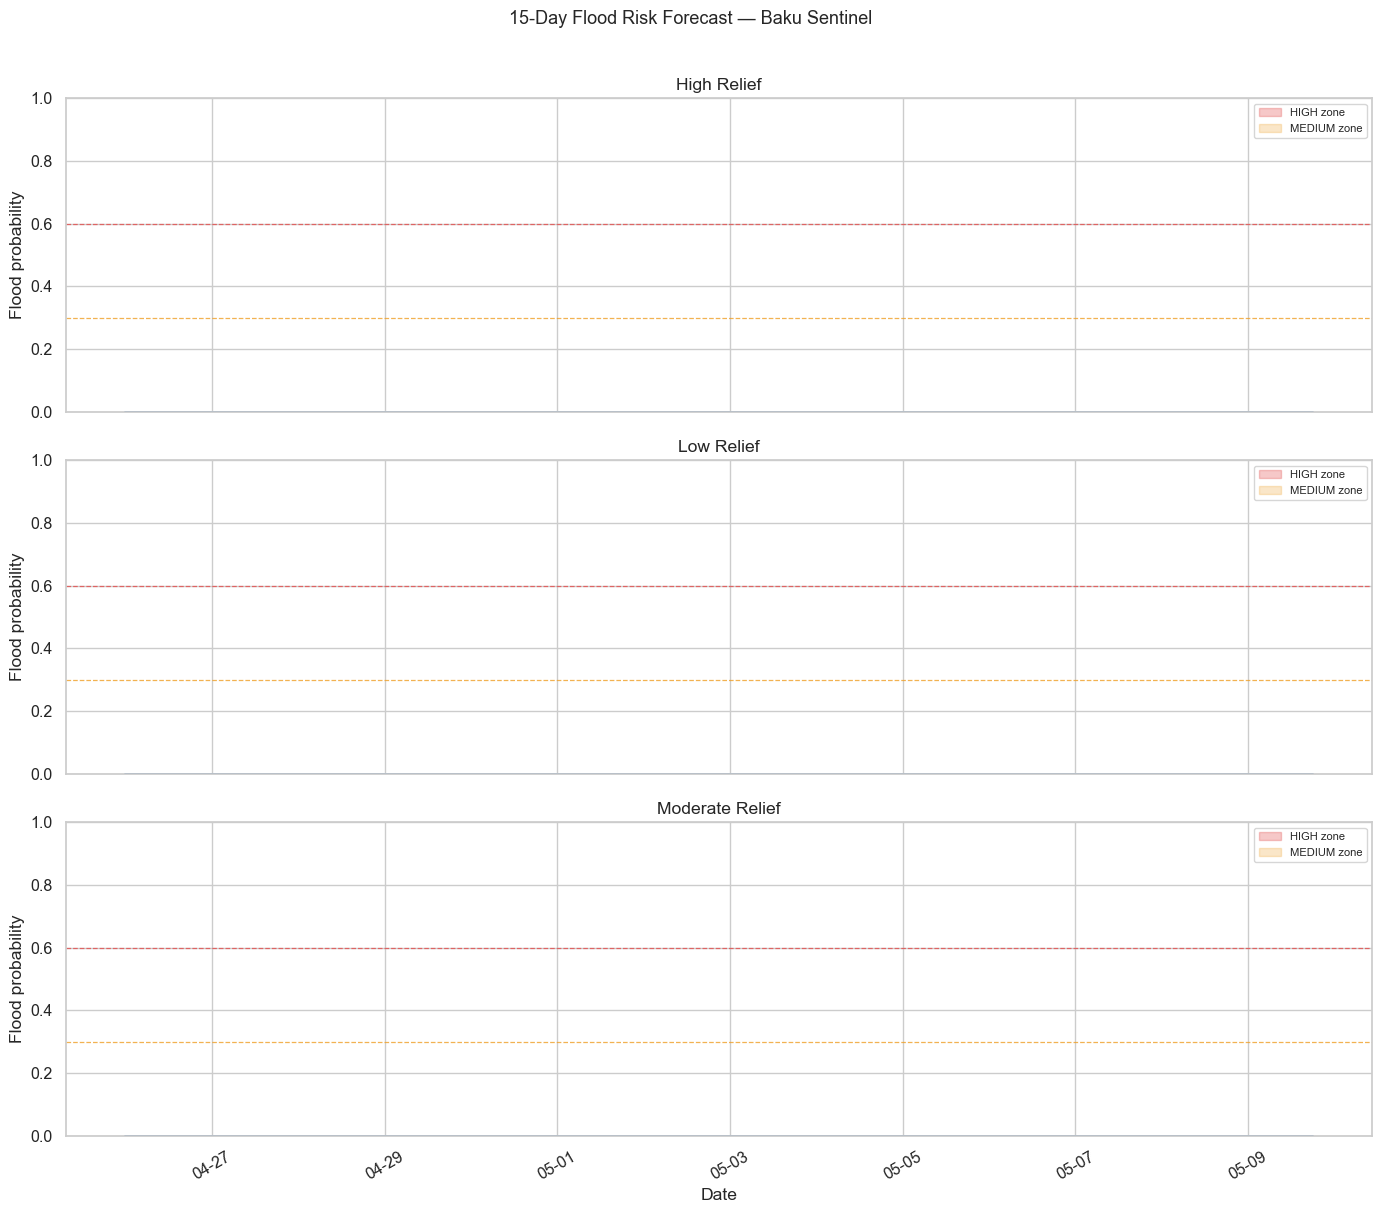

In [42]:
fig, axes = plt.subplots(len(config.BAKU_ZONES), 1,
                          figsize=(14, 4 * len(config.BAKU_ZONES)), sharex=True)

for ax, zone_cfg in zip(axes, config.BAKU_ZONES):
    zone = zone_cfg['zone']
    zdf  = df_predicted[df_predicted['zone'] == zone].sort_values('time_6h')

    ax.fill_between(zdf['time_6h'], zdf['risk_score'],
                    where=zdf['risk_score'] >= config.RISK_HIGH,
                    alpha=0.3, color='#E24B4A', label='HIGH zone')
    ax.fill_between(zdf['time_6h'], zdf['risk_score'],
                    where=(zdf['risk_score'] >= config.RISK_MEDIUM) & (zdf['risk_score'] < config.RISK_HIGH),
                    alpha=0.25, color='#EF9F27', label='MEDIUM zone')
    ax.plot(zdf['time_6h'], zdf['risk_score'], lw=1.2, color='#185FA5')

    ax.axhline(config.RISK_HIGH,   color='#E24B4A', linestyle='--', lw=0.9, alpha=0.8)
    ax.axhline(config.RISK_MEDIUM, color='#EF9F27', linestyle='--', lw=0.9, alpha=0.8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Flood probability')
    ax.set_title(f'{zone}')
    ax.legend(fontsize=8, loc='upper right')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
axes[-1].set_xlabel('Date')
plt.suptitle(f'15-Day Flood Risk Forecast — Baku Sentinel', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 7.5 · Alert summary

In [43]:
ALERT_ICONS = {'HIGH': '⚠️ ', 'MEDIUM': '🟡', 'LOW': '🟢'}

for _, row in summary.iterrows():
    zone      = row.name
    max_risk  = row['max_risk']
    high_p    = int(row['high_risk_periods'])
    if max_risk >= config.RISK_HIGH:
        level = 'HIGH'
    elif max_risk >= config.RISK_MEDIUM:
        level = 'MEDIUM'
    else:
        level = 'LOW'
    icon = ALERT_ICONS[level]
    print(f"{icon}  {zone:20s}  peak={max_risk*100:.1f}%  "
          f"high-risk 6h-periods={high_p}  level={level}")

🟢  High Relief           peak=0.0%  high-risk 6h-periods=0  level=LOW
🟢  Low Relief            peak=0.0%  high-risk 6h-periods=0  level=LOW
🟢  Moderate Relief       peak=0.0%  high-risk 6h-periods=0  level=LOW
